# Machine Learning Project
## Part 2: Clustering and Classification for `poutcome`

**Prepared by:** [Student Name]  
**Course:** Machine Learning  
**Dataset:** `bank.csv`

In this part I focus on two main things:
1. trying K-Means as an unsupervised method,
2. training supervised models to predict `poutcome`.

I dropped `deposit` from the modeling features because the project is asking to classify `poutcome`, so I did not want to keep an extra target-like column in the input.

### 1. Imports

The code below loads the libraries I need for preprocessing, clustering, model tuning, and evaluation.

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    normalized_mutual_info_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### 2. Load the data and inspect the target

Before training anything, I want to see the dataset shape and the distribution of the `poutcome` classes.

Rows: 11162
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


,count,percentage
poutcome,,
unknown,8326,74.59
failure,1228,11.00
success,1071,9.60
other,537,4.81


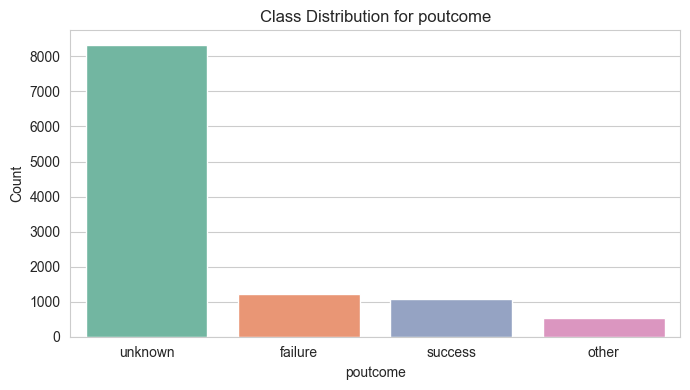

In [2]:
df = pd.read_csv("bank.csv")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

target_summary = pd.DataFrame(
    {
        "count": df["poutcome"].value_counts(),
        "percentage": (df["poutcome"].value_counts(normalize=True) * 100).round(2),
    }
)

display(target_summary)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="poutcome", order=target_summary.index, palette="Set2")
plt.title("Class Distribution for poutcome")
plt.xlabel("poutcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The target is clearly imbalanced because most records are labeled as `unknown`. This is important because accuracy alone may look high even if the smaller classes are not predicted well.

### 3. Prepare the data for supervised models

I used one-hot encoding for categorical columns and standard scaling for the numerical columns. The target here is `poutcome`.

In [3]:
X = df.drop(columns=["poutcome", "deposit"]).copy()
y = df["poutcome"].copy()

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Encoded feature count:", X_encoded.shape[1])

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']
Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Encoded feature count: 47


In [4]:
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = list(label_encoder.classes_)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

class_mapping = pd.DataFrame(
    {"class_id": range(len(class_names)), "poutcome": class_names}
)
display(class_mapping)

Train shape: (8929, 47)
Test shape: (2233, 47)


,class_id,poutcome
0,0,failure
1,1,other
2,2,success
3,3,unknown


### 4. Unsupervised learning with K-Means

For clustering, the assignment says to remove both `poutcome` and `deposit`, so I prepare a separate feature matrix for K-Means.

,k,inertia
0,2,110892.164516
1,3,103509.201531
2,4,97522.463819
3,5,91999.614663
4,6,87114.820131
5,7,82880.083206
6,8,79525.860460


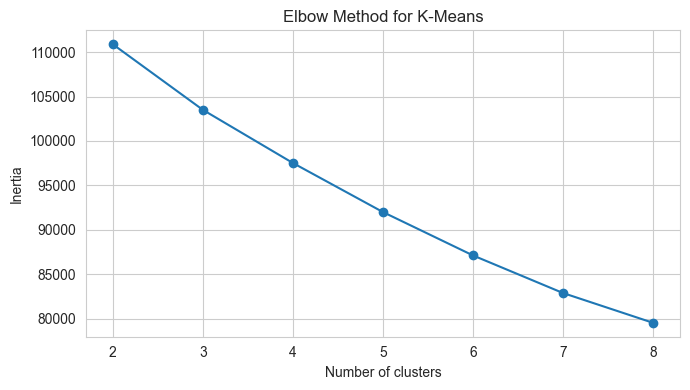

In [5]:
cluster_X = df.drop(columns=["poutcome", "deposit"]).copy()
cluster_cat_cols = cluster_X.select_dtypes(include="object").columns.tolist()
cluster_num_cols = cluster_X.select_dtypes(include=np.number).columns.tolist()

cluster_encoded = pd.get_dummies(cluster_X, columns=cluster_cat_cols, drop_first=False)
cluster_encoded[cluster_num_cols] = StandardScaler().fit_transform(
    cluster_encoded[cluster_num_cols]
)

inertias = []
k_values = list(range(2, 9))

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(cluster_encoded)
    inertias.append(kmeans.inertia_)

elbow_table = pd.DataFrame({"k": k_values, "inertia": inertias})
display(elbow_table)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [6]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(cluster_encoded)

ari = adjusted_rand_score(df["poutcome"], cluster_labels)
nmi = normalized_mutual_info_score(df["poutcome"], cluster_labels)

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

cluster_vs_class = pd.crosstab(
    pd.Series(cluster_labels, name="cluster"),
    df["poutcome"],
)
display(cluster_vs_class)

Adjusted Rand Index: 0.308
Normalized Mutual Information: 0.338


poutcome,failure,other,success,unknown
cluster,,,,
0,142,67,270,2644
1,109,60,173,5215
2,3,2,1,466
3,974,408,627,1


**K-Means notes**

- The elbow curve gives a rough bend around the lower values of `k`, but it is not a very sharp elbow.
- I used `k=4` to make the comparison easier with the four real `poutcome` classes.
- The clustering does not match the true labels very well, which is expected because K-Means is not directly optimizing class separation.
- The strong dominance of the `unknown` class makes the clustering problem harder.

### 5. Baseline models before tuning

I first train simple default versions so I can compare them later with the tuned versions.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    "MLP default": MLPClassifier(
        random_state=42,
        max_iter=250,
        early_stopping=True,
        n_iter_no_change=15,
    ),
    "Gradient Boosting default": GradientBoostingClassifier(random_state=42),
}

baseline_rows = []

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    baseline_pred = model.predict(X_test)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        baseline_pred,
        average="macro",
        zero_division=0,
    )

    baseline_rows.append(
        {
            "model": model_name,
            "test_accuracy": accuracy_score(y_test, baseline_pred),
            "macro_f1": macro_f1,
        }
    )

baseline_results = pd.DataFrame(baseline_rows).sort_values(
    by="test_accuracy",
    ascending=False,
)
display(baseline_results.round(4))

,model,test_accuracy,macro_f1
1,Gradient Boosting default,0.9046,0.6293
0,MLP default,0.8957,0.6147


### 6. Hyperparameter tuning with stratified k-fold cross validation

I use `GridSearchCV` with `f1_macro` because the classes are imbalanced and I do not want the large `unknown` class to dominate the score too much.

In [8]:
mlp = MLPClassifier(
    random_state=42,
    max_iter=250,
    early_stopping=True,
    n_iter_no_change=15,
)

mlp_param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [32, 64],
}

mlp_search = GridSearchCV(
    estimator=mlp,
    param_grid=mlp_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

mlp_search.fit(X_train, y_train)

print("Best MLP parameters:", mlp_search.best_params_)
print(f"Best MLP CV score: {mlp_search.best_score_:.4f}")

Best MLP parameters: {'batch_size': 32, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01}
Best MLP CV score: 0.5810


In [9]:
gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
}

gb_search = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train)

print("Best Gradient Boosting parameters:", gb_search.best_params_)
print(f"Best Gradient Boosting CV score: {gb_search.best_score_:.4f}")

Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best Gradient Boosting CV score: 0.6125


In [10]:
mlp_tuning_table = (
    pd.DataFrame(mlp_search.cv_results_)[
        ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    ]
    .sort_values(by=["rank_test_score", "mean_test_score"])
    .head(5)
)

gb_tuning_table = (
    pd.DataFrame(gb_search.cv_results_)[
        ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    ]
    .sort_values(by=["rank_test_score", "mean_test_score"])
    .head(5)
)

print("Top MLP combinations")
display(mlp_tuning_table)

print("Top Gradient Boosting combinations")
display(gb_tuning_table)

Top MLP combinations


,params,mean_test_score,std_test_score,rank_test_score
3,"{'batch_size': 32, 'hidden_layer_sizes': (128,...",0.581034,0.015582,1
8,"{'batch_size': 64, 'hidden_layer_sizes': (128,...",0.580704,0.020081,2
9,"{'batch_size': 64, 'hidden_layer_sizes': (128,...",0.580340,0.006121,3
10,"{'batch_size': 64, 'hidden_layer_sizes': (64, ...",0.577890,0.016489,4
2,"{'batch_size': 32, 'hidden_layer_sizes': (128,...",0.576107,0.013998,5


Top Gradient Boosting combinations


,params,mean_test_score,std_test_score,rank_test_score
7,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.612520,0.010508,1
3,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.612378,0.012752,2
2,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.609923,0.014719,3
4,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.609032,0.015957,4
5,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.608501,0.016078,5


### 7. Final evaluation on the training and test sets

In this section I evaluate the best tuned model from each algorithm and compare train vs test performance.

In [11]:
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test, class_names):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        test_pred,
        average="macro",
        zero_division=0,
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_test,
        test_pred,
        average="micro",
        zero_division=0,
    )

    report_df = pd.DataFrame(
        classification_report(
            y_test,
            test_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).T
    report_df.loc["micro avg"] = [micro_p, micro_r, micro_f1, len(y_test)]

    summary = {
        "model": model_name,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
    }

    cm = confusion_matrix(y_test, test_pred)
    return summary, report_df, cm


tuned_models = {
    "MLP tuned": mlp_search.best_estimator_,
    "Gradient Boosting tuned": gb_search.best_estimator_,
}

evaluation_rows = []
detailed_reports = {}
confusion_matrices = {}

for model_name, model in tuned_models.items():
    summary, report_df, cm = evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        class_names,
    )
    evaluation_rows.append(summary)
    detailed_reports[model_name] = report_df
    confusion_matrices[model_name] = cm

comparison_df = pd.DataFrame(evaluation_rows).sort_values(
    by="test_accuracy",
    ascending=False,
)
display(comparison_df.round(4))

,model,train_accuracy,test_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1
1,Gradient Boosting tuned,0.9346,0.9060,0.6500,0.6492,0.6323,0.9060,0.9060,0.9060
0,MLP tuned,0.9027,0.8948,0.6461,0.6264,0.6177,0.8948,0.8948,0.8948


In [12]:
for model_name, report_df in detailed_reports.items():
    print(model_name)
    display(
        report_df.loc[
            class_names + ["macro avg", "weighted avg", "micro avg"]
        ].round(4)
    )

MLP tuned


,precision,recall,f1-score,support
failure,0.5932,0.7114,0.6470,246.0
other,0.3824,0.1215,0.1844,107.0
success,0.6102,0.6729,0.6400,214.0
unknown,0.9988,1.0000,0.9994,1666.0
macro avg,0.6461,0.6264,0.6177,2233.0
weighted avg,0.8873,0.8948,0.8871,2233.0
micro avg,0.8948,0.8948,0.8948,2233.0


Gradient Boosting tuned


,precision,recall,f1-score,support
failure,0.6318,0.7602,0.6900,246.0
other,0.3000,0.0841,0.1314,107.0
success,0.6680,0.7523,0.7077,214.0
unknown,1.0000,1.0000,1.0000,1666.0
macro avg,0.6500,0.6492,0.6323,2233.0
weighted avg,0.8941,0.9060,0.8962,2233.0
micro avg,0.9060,0.9060,0.9060,2233.0


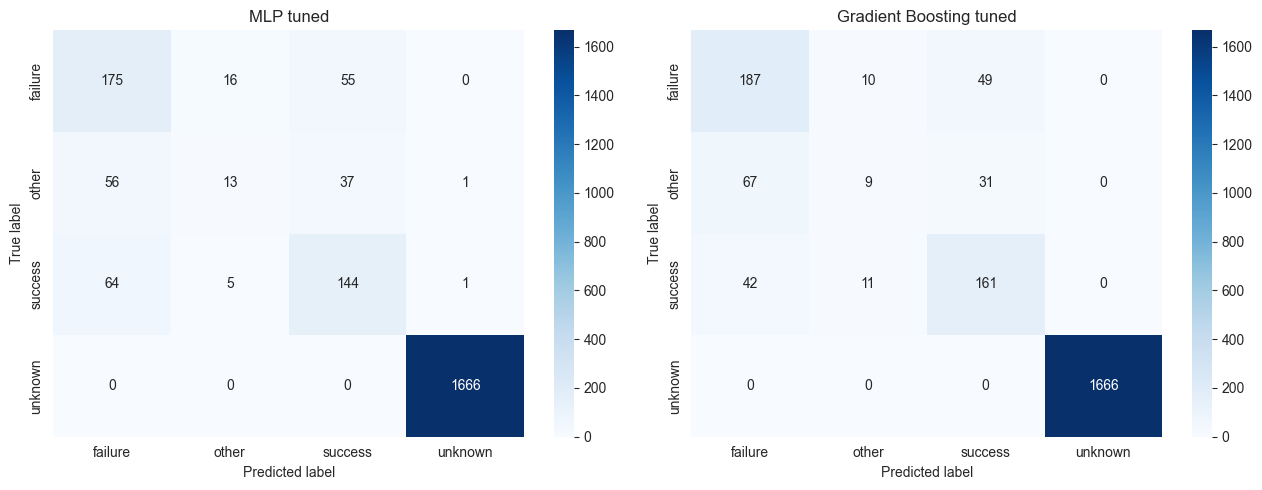

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

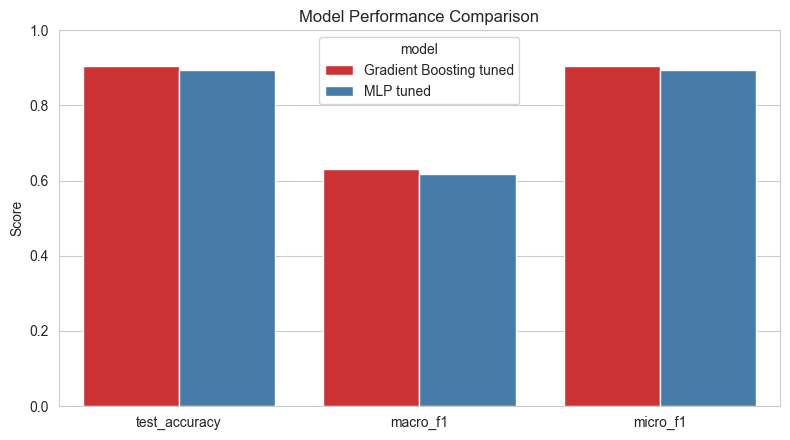

In [14]:
plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=["test_accuracy", "macro_f1", "micro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model", palette="Set1")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

### 8. Short discussion

From my runs, Gradient Boosting gave the best overall test performance, with test accuracy around `0.906` and a slightly better macro F1 than the MLP model.

A few points stood out:

- Hyperparameter tuning helped, but the improvement was not huge.
- The `unknown` class was the easiest one because it has the largest number of samples.
- The `other` class was the hardest one and got the weakest recall in both models.
- K-Means was not a strong match for the real labels, which shows the limitation of unsupervised learning for this task.

If I continue this work later, I would try class balancing, a larger hyperparameter search, and maybe stronger tree-based models.